In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from neural_network import NeuralNetwork

In [2]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

nn_xor = NeuralNetwork(input_size=2, hidden_size=4, output_size=1, random_seed=0)
nn_xor.fit(X_xor, y_xor, lr=0.5, n_iterations=5000)

probs = nn_xor.predict_proba(X_xor).ravel()
preds = nn_xor.predict(X_xor).ravel()

for inputs, prob, pred, true in zip(X_xor, probs, preds, y_xor):
    print(f"{inputs.astype(int)} -> P(1)={prob:.4f}  predicted={pred}  actual={true}")

[0 0] -> P(1)=0.0021  predicted=0  actual=0
[0 1] -> P(1)=0.9997  predicted=1  actual=1
[1 0] -> P(1)=0.9997  predicted=1  actual=1
[1 1] -> P(1)=0.0002  predicted=0  actual=0


In [3]:
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

nn = NeuralNetwork(input_size=X.shape[1], hidden_size=16, output_size=1, random_seed=42)
nn.fit(X_train_s, y_train, lr=0.1, n_iterations=3000)

preds = nn.predict(X_test_s)
print(f"Test accuracy: {accuracy_score(y_test, preds):.3f}")

Test accuracy: 0.965


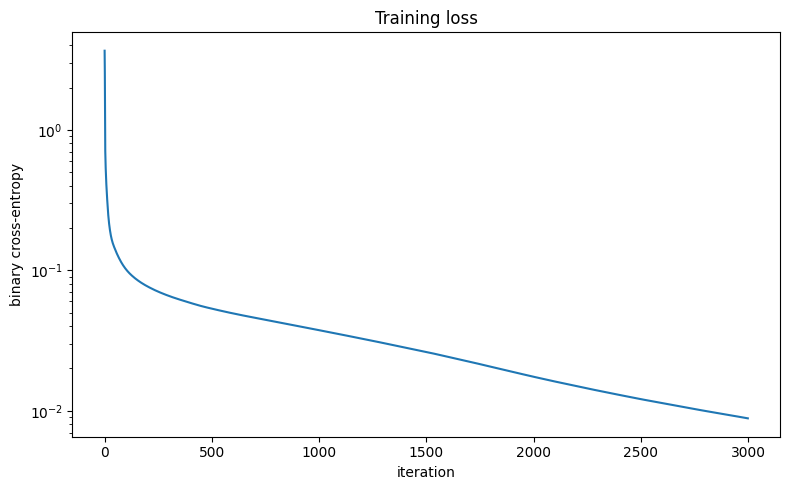

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(nn.loss_history_)

ax.set_xlabel("iteration")
ax.set_ylabel("binary cross-entropy")
ax.set_title("Training loss")

plt.tight_layout()
plt.show()

Test accuracy: 0.920


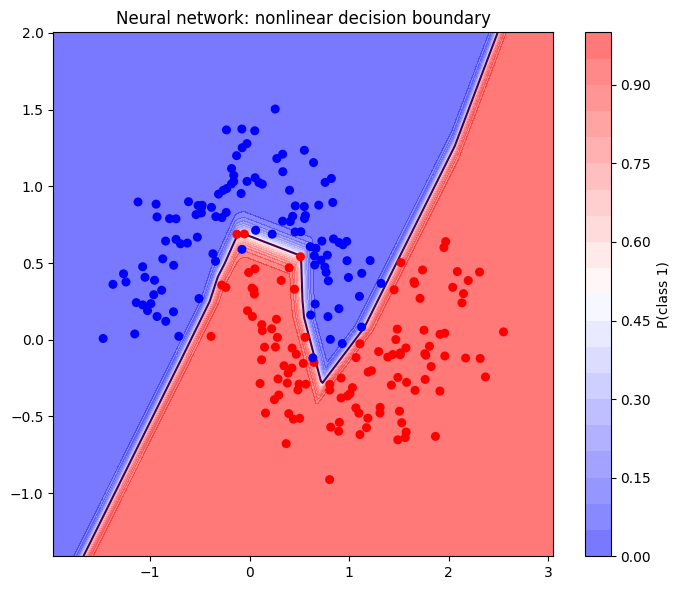

In [5]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=300, noise=0.2, random_state=42)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    Xm, ym, test_size=0.25, random_state=42, stratify=ym
)

nn_moons = NeuralNetwork(input_size=2, hidden_size=16, output_size=1, random_seed=42)
nn_moons.fit(Xm_train, ym_train, lr=0.5, n_iterations=5000)
print(f"Test accuracy: {accuracy_score(ym_test, nn_moons.predict(Xm_test)):.3f}")

CLASS_COLORS = ["b", "r"]
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "colormap", ["b", "w", "r"]
)

pad = 0.5
x_min, x_max = Xm[:, 0].min() - pad, Xm[:, 0].max() + pad
y_min, y_max = Xm[:, 1].min() - pad, Xm[:, 1].max() + pad
xv, yv = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = nn_moons.predict_proba(np.c_[xv.ravel(), yv.ravel()]).reshape(xv.shape)

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(xv, yv, Z, levels=20, cmap=DIVERGING_CMAP, alpha=0.55, vmin=0, vmax=1)
ax.contour(xv, yv, Z, levels=[0.5], zorder=2)
ax.scatter(
    Xm_train[:, 0], Xm_train[:, 1],
    c=[CLASS_COLORS[c] for c in ym_train],
    s=30, zorder=3,
)

ax.set_title("Neural network: nonlinear decision boundary")
fig.colorbar(cf, ax=ax, label="P(class 1)")

plt.tight_layout()
plt.show()